<a href="https://colab.research.google.com/github/thisishasan/cbir_system/blob/main/30_image_reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [219]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [220]:
%cd '/content/drive/My Drive/01_information_retrieval'

/content/drive/My Drive/01_information_retrieval


In [221]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

In [222]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [223]:
class ConvAutoEncoder:
    @staticmethod
    def build(width, height, depth, filters=(128,), latent_dim=48):
        input_shape = (height, width, depth)
        channel_dim = -1
        inputs = Input(shape=input_shape)
        x = inputs
        # Encoder layer
        for f in filters:
            x = Conv2D(f, (3, 3), strides=2, padding='same')(x)
            x = LeakyReLU(negative_slope=0.2)(x)
            x = BatchNormalization(axis=channel_dim, name='enc_filter_'+str(f))(x)

        volume_size = K.int_shape(x)
        x = Flatten()(x)
        # Latent layer
        latent = Dense(latent_dim, name="encoded")(x)

        # Decoder layer
        x = Dense(int(np.prod(volume_size[1:])))(latent)
        x = Reshape((volume_size[1], volume_size[2], volume_size[3]))(x)

        # Reverse on decoder
        for f in filters[::-1]:
            x = Conv2DTranspose(f, (3, 3), strides=2, padding='same')(x)
            x = LeakyReLU(negative_slope=0.2)(x)
            x = BatchNormalization(axis=channel_dim, name='dec_filter_'+str(f))(x)

        x = Conv2DTranspose(depth, (3, 3), padding="same")(x)
        outputs = Activation("sigmoid", name="decoded")(x)

        auto_encoder = Model(inputs, outputs, name="auto_encoder")
        return auto_encoder

In [224]:
base_dataset = "binary_scenario"
class_dir = ['benign', 'malignant']
IMAGE_SIZE = (256, 256)
magnification = "400X"
weights_file = "training_1_400/cp.ckpt.weights.h5"
indexed_json_file = "training_1_indexed_400.json"

In [225]:
auto_encoder = ConvAutoEncoder.build(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
auto_encoder.load_weights(weights_file)

In [226]:
dataset_test = []
dataset_test.append("binary_scenario/test/400X/benign/SOB_B_TA-14-19854C-400-012.png")
dataset_test.append("binary_scenario/test/400X/malignant/SOB_M_DC-14-5694-400-003.png")

In [227]:
images_test = []
for image_path in dataset_test:
    if "png" in image_path:
        image = cv2.imread(image_path)
        image = cv2.resize(image, IMAGE_SIZE)
        images_test.append(image)

In [228]:
test_x = np.array(images_test).astype("float32") / 255.0

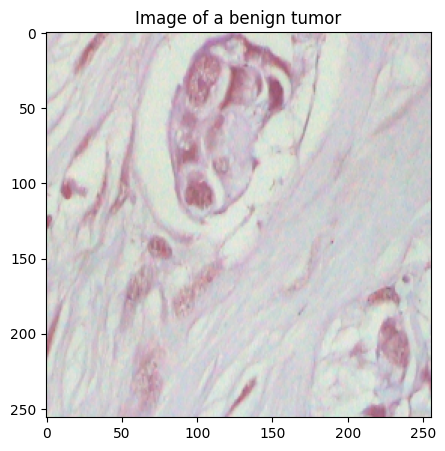

In [229]:
plt.figure(figsize=(5,5))
plt.imshow(test_x[0])
plt.title("Image of a benign tumor")
plt.show()

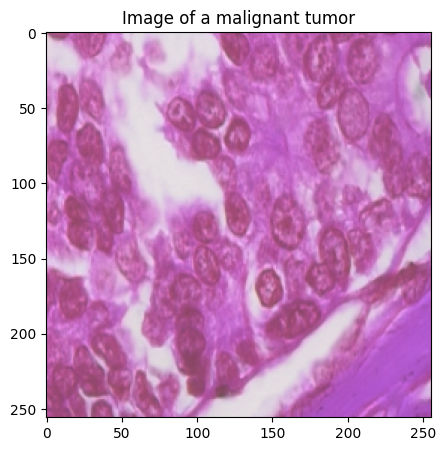

In [230]:
plt.figure(figsize=(5,5))
plt.imshow(test_x[1])
plt.title("Image of a malignant tumor")
plt.show()

In [231]:
decoded = auto_encoder.predict(test_x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step


In [232]:
reconstruction_benign = (decoded[0] * 255).astype("uint8")
reconstruction_malignant = (decoded[1] * 255).astype("uint8")

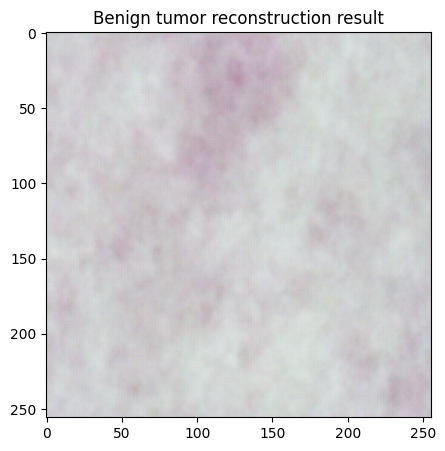

In [233]:
plt.figure(figsize=(5,5))
plt.imshow(reconstruction_benign)
plt.title("Benign tumor reconstruction result")
plt.show()

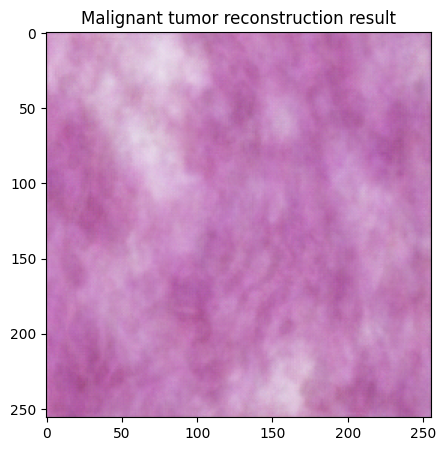

In [234]:
plt.figure(figsize=(5,5))
plt.imshow(reconstruction_malignant)
plt.title("Malignant tumor reconstruction result")
plt.show()